# Homework 9: Linear Classification of Breast Cancer Malignancy

### Part 1: Data Retrieval

In [1]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [21]:
# Counting number of features
print(len(data.feature_names))

# Determining what the features represent
data.feature_names

# Different classes in target variable
data.target_names

# Number of samples in the dataset
print(len(data.data))

30
569


There are 30 features in the dataset.

The features represent components of the breast masses and properties of the cell nuclei, including mean, standard error, and worst (largest) measurements. Other features include radius, texture, perimeter, and concavity. These are quantitative features of the tumor cell nuclei.

There are two classes in the target variable: malignant, benign

There are 569 samples (number of rows in data.data) in the dataset.

### Part 2: Data Preparation

In [126]:
from sklearn.model_selection import train_test_split
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 1)

75% of the data is in the training set. This proportion was chosen after using a test size of 0.3 as a base and seeing which proportion would return an accuracy score closest to 1.

### Part 3: Fitting a Linear Classifier

In [127]:
from sklearn.linear_model import SGDClassifier
clf = SGDClassifier(loss = "perceptron", alpha = 0.01)
clf.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'perceptron'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.01
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


This algorithm is designed to work with data using regularized linear models and works with data represented as a "dense or sparse array of floating point values for the features" (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#). Peceptron is a linear binary classifier.

The breast cancer dataset, while perfectly not linearly separable, can still be used since it can divide tumors as malignant or benign.

### Part 4: Validation and Assessment

In [128]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
accuracy_test = accuracy_score(y_test, clf.predict(X_test))
accuracy_train = accuracy_score(y_train, clf.predict(X_train))

Train accuracy: 0.9225352112676056; Test accuracy: 0.9440559440559441


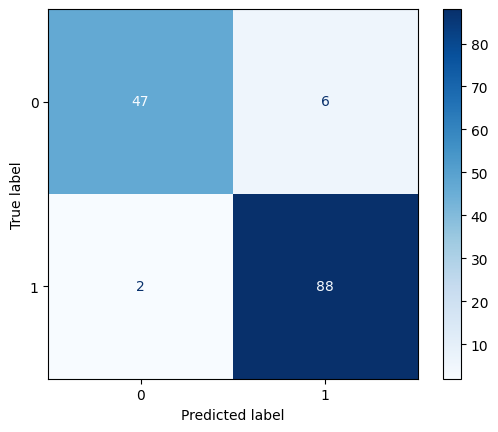

In [130]:
print(f"Train accuracy: {accuracy_train}; Test accuracy: {accuracy_test}")
cm_display = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap = plt.cm.Blues, normalize = None)

0 = malignant, 1 = benign

The model performs highly accurately, as only two tumors were misidentified as malignant when they were benign, and six benign tumors were misidentified as malignant when they were benign. The overall misidentification ratio based on the samples used for the confusion matrix is 0.0559, or roughly 5.6% of the samples were misidentified.

In this context, misclassifying malignant tumors as benign (false negative) is more consequential since it could lead to an overlooked cancer diagnosis.